In [18]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn joblib


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\Gunjan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

In [20]:
df = pd.read_csv('../data/cleaned_data.csv')

print(f'Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\n Target distribution:')
print(df['readmitted_30'].value_counts())
print(f'\nClass imbalance ratio: {df["readmitted_30"].value_counts()[0] / df["readmitted_30"].value_counts()[1]:.1f}:1')
df.head()

Loaded dataset: 101,766 rows × 44 columns

 Target distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Class imbalance ratio: 8.0:1


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30
0,2,0,0,6,25,1,1,7,41,0,1,0,0,0,7,7,1,1,1,1,1,1,1,0,1,1,0,1,1,1,1,0,0,0,0,1,1,0,0,0,0,1,0,0
1,2,0,1,1,1,7,3,7,59,0,18,0,0,0,7,7,7,9,1,1,1,1,1,0,1,1,0,1,1,1,1,0,0,0,0,3,1,0,0,0,0,0,1,0
2,0,0,2,1,1,7,2,7,11,5,13,2,0,1,7,1,7,6,1,1,1,1,1,0,2,1,0,1,1,1,1,0,0,0,0,1,1,0,0,0,0,1,1,0
3,2,1,3,1,1,7,2,7,44,1,16,0,0,0,7,7,0,7,1,1,1,1,1,0,1,1,0,1,1,1,1,0,0,0,0,3,1,0,0,0,0,0,1,0
4,2,1,4,1,1,7,1,7,51,0,8,0,0,0,6,6,1,5,1,1,1,1,1,0,2,1,0,1,1,1,1,0,0,0,0,2,1,0,0,0,0,0,1,0


In [21]:
X = df.drop(columns=['readmitted_30'])
y = df['readmitted_30']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'\nFeature columns ({len(X.columns)}):')
print(list(X.columns))

Features (X): (101766, 43)
Target  (y): (101766,)

Feature columns (43):
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f' Train set: {X_train.shape[0]:,} samples')
print(f' Test set:  {X_test.shape[0]:,} samples')
print(f'\nBefore SMOTE — Train class distribution:')
print(y_train.value_counts())

 Train set: 81,412 samples
 Test set:  20,354 samples

Before SMOTE — Train class distribution:
readmitted_30
0    72326
1     9086
Name: count, dtype: int64


In [23]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'After SMOTE — Train class distribution:')
print(pd.Series(y_train_sm).value_counts())
print(f'\n Training set size after SMOTE: {X_train_sm.shape[0]:,} samples (balanced)')

After SMOTE — Train class distribution:
readmitted_30
0    72326
1    72326
Name: count, dtype: int64

 Training set size after SMOTE: 144,652 samples (balanced)


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for Flask API use
joblib.dump(scaler, '../models/scaler.pkl')
print(' Features scaled using StandardScaler')
print(' Scaler saved to models/scaler.pkl')

 Features scaled using StandardScaler
 Scaler saved to models/scaler.pkl


In [25]:
# Define all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}

# Train and evaluate all models
results = []
trained_models = {}

print('Training models...\n')
for name, model in models.items():
    print(f'  Training {name}...', end=' ')

    # Use scaled data for Logistic Regression, unscaled for tree-based
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_sm)
        y_pred  = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_sm, y_train_sm)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    results.append({
        'Model': name,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1-Score':  round(f1,   4),
        'AUC-ROC':   round(auc,  4)
    })
    trained_models[name] = (model, y_pred, y_proba)
    print(f'Done! | Acc: {acc:.3f} | AUC: {auc:.3f}')

print('\n All models trained!')

Training models...

  Training Logistic Regression... Done! | Acc: 0.694 | AUC: 0.543
  Training Decision Tree... Done! | Acc: 0.742 | AUC: 0.534
  Training Random Forest... Done! | Acc: 0.850 | AUC: 0.582
  Training XGBoost... Done! | Acc: 0.825 | AUC: 0.588

 All models trained!


In [26]:
results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)

# Highlight best values
print(' Model Comparison Table:')
display(results_df.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','AUC-ROC'],
                   color='#d4f5d4')
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}',
             'Recall':'{:.4f}','F1-Score':'{:.4f}','AUC-ROC':'{:.4f}'})
    .set_properties(**{'font-size':'13px'})
)

 Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
3,XGBoost,0.8246,0.1795,0.1603,0.1693,0.5880
2,Random Forest,0.8504,0.1764,0.0929,0.1217,0.5820
0,Logistic Regression,0.6938,0.1337,0.3184,0.1883,0.5429
1,Decision Tree,0.7423,0.1230,0.2136,0.1561,0.5337


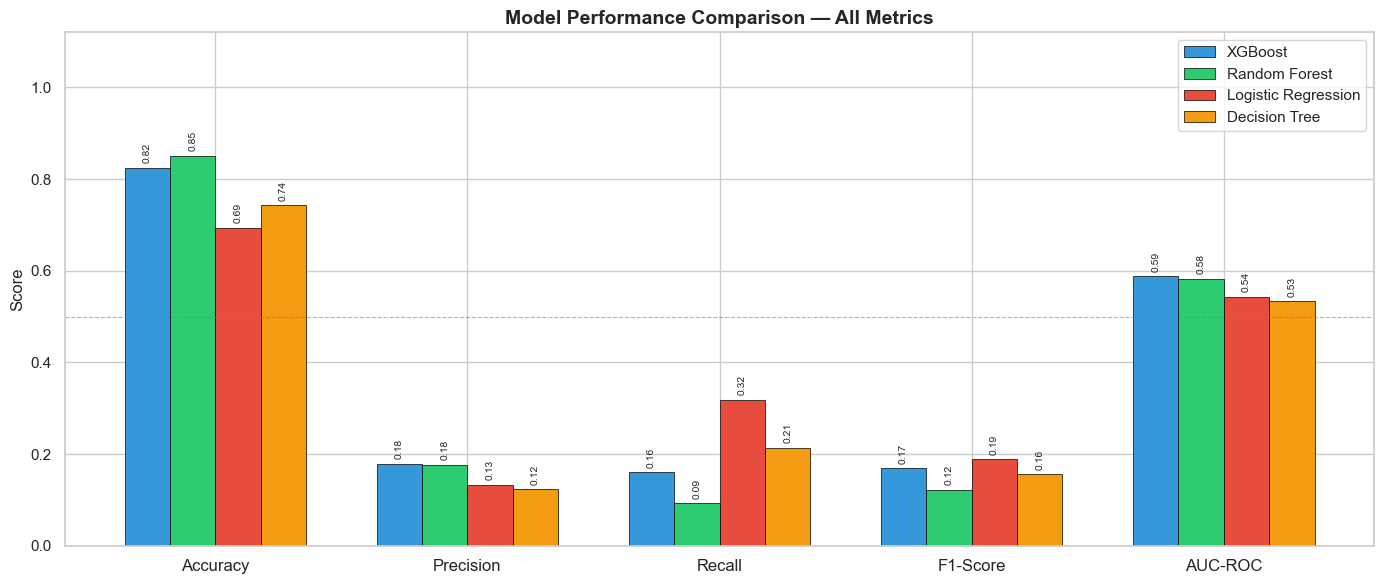

 Saved: ../outputImg/chart1_model_comparison.png


In [27]:
# ----- CHART 1: Grouped Bar Chart — All Metrics -----
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.18
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=row['Model'],
                  color=colors[i], edgecolor='black', linewidth=0.5)

ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for bar_group_start in range(len(results_df)):
    for j, metric in enumerate(metrics):
        val = results_df.iloc[bar_group_start][metric]
        ax.text(j + bar_group_start * width, val + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

plt.tight_layout()
plt.savefig('../outputImg/chart21_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: ../outputImg/chart1_model_comparison.png')

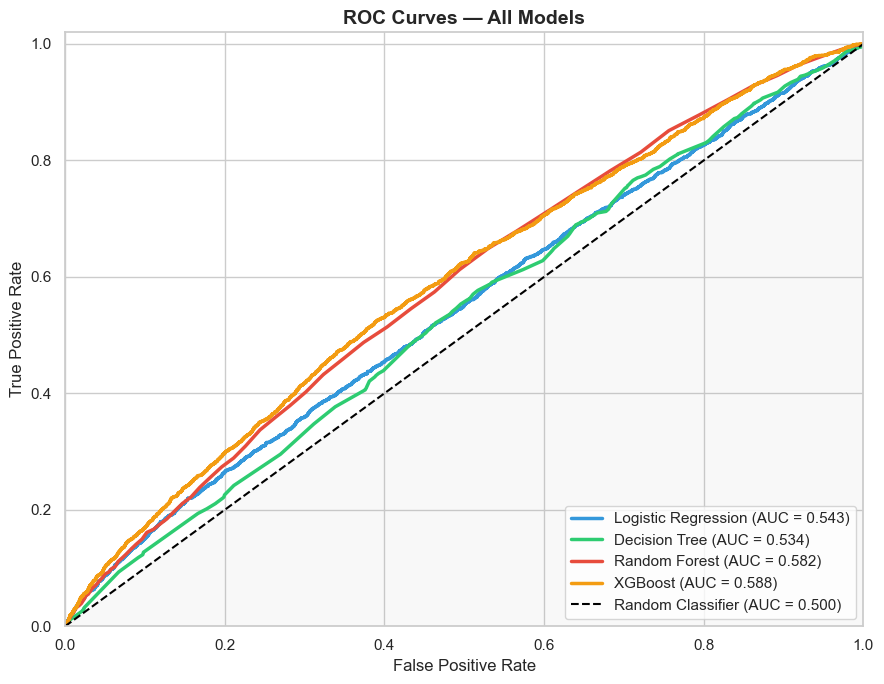

💾 Saved: ../outputImg/chart2_roc_curves.png


In [28]:
# ----- CHART 2: ROC Curves for All Models -----
fig, ax = plt.subplots(figsize=(9, 7))

for i, (name, (model, y_pred, y_proba)) in enumerate(trained_models.items()):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2.5, color=colors[i], label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../outputImg/chart22_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ../outputImg/chart2_roc_curves.png')

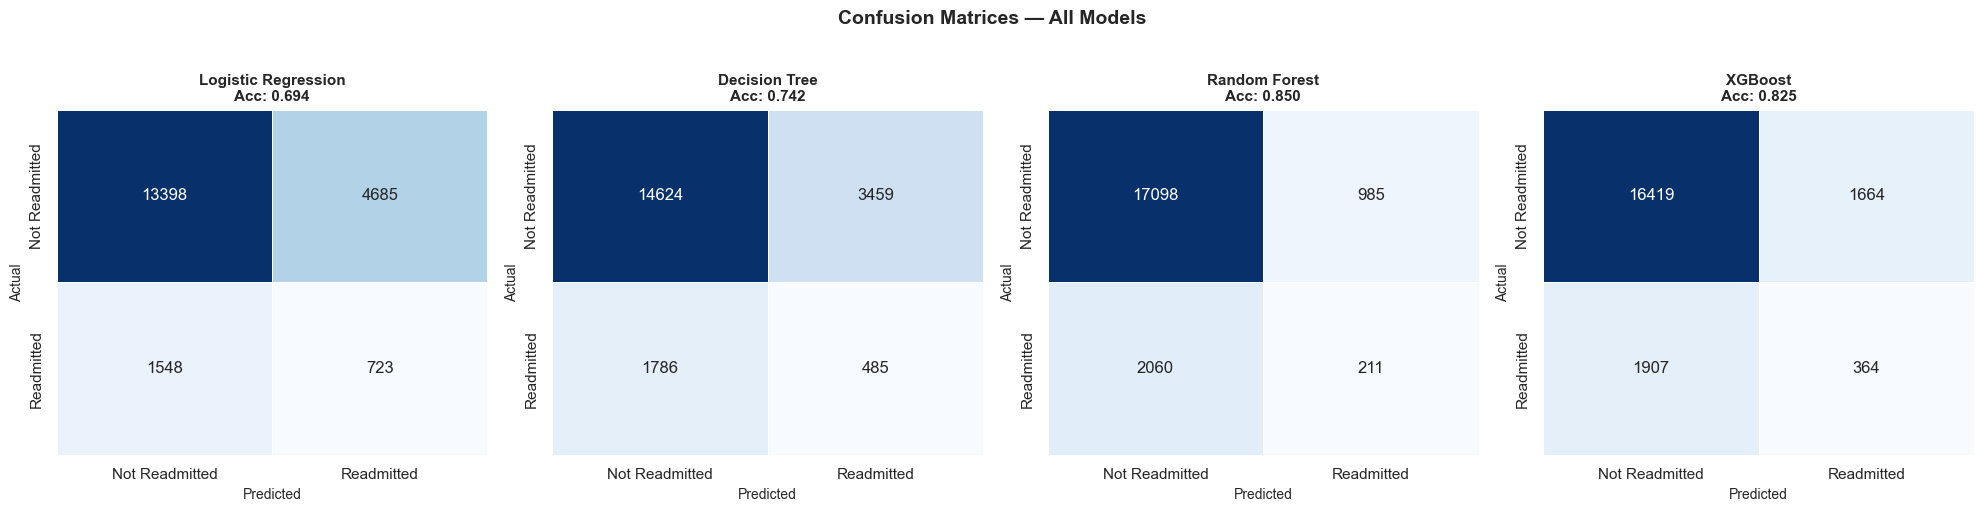

Saved: ../outputImg/chart3_confusion_matrices.png


In [29]:
# ----- CHART 3: Confusion Matrices for All Models -----
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, (model, y_pred, y_proba)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, y_pred):.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputImg/chart23_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../outputImg/chart3_confusion_matrices.png')

In [30]:
# Select best model by AUC-ROC
best_model_name = results_df.iloc[0]['Model']
best_model, best_y_pred, best_y_proba = trained_models[best_model_name]

print(f' Best Model: {best_model_name}')
print(f'   AUC-ROC:   {results_df.iloc[0]["AUC-ROC"]:.4f}')
print(f'   Accuracy:  {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'   F1-Score:  {results_df.iloc[0]["F1-Score"]:.4f}')
print(f'\n Detailed Classification Report:')
print(classification_report(y_test, best_y_pred,
                             target_names=['Not Readmitted', 'Readmitted <30d']))

 Best Model: XGBoost
   AUC-ROC:   0.5880
   Accuracy:  0.8246
   F1-Score:  0.1693

 Detailed Classification Report:
                 precision    recall  f1-score   support

 Not Readmitted       0.90      0.91      0.90     18083
Readmitted <30d       0.18      0.16      0.17      2271

       accuracy                           0.82     20354
      macro avg       0.54      0.53      0.54     20354
   weighted avg       0.82      0.82      0.82     20354



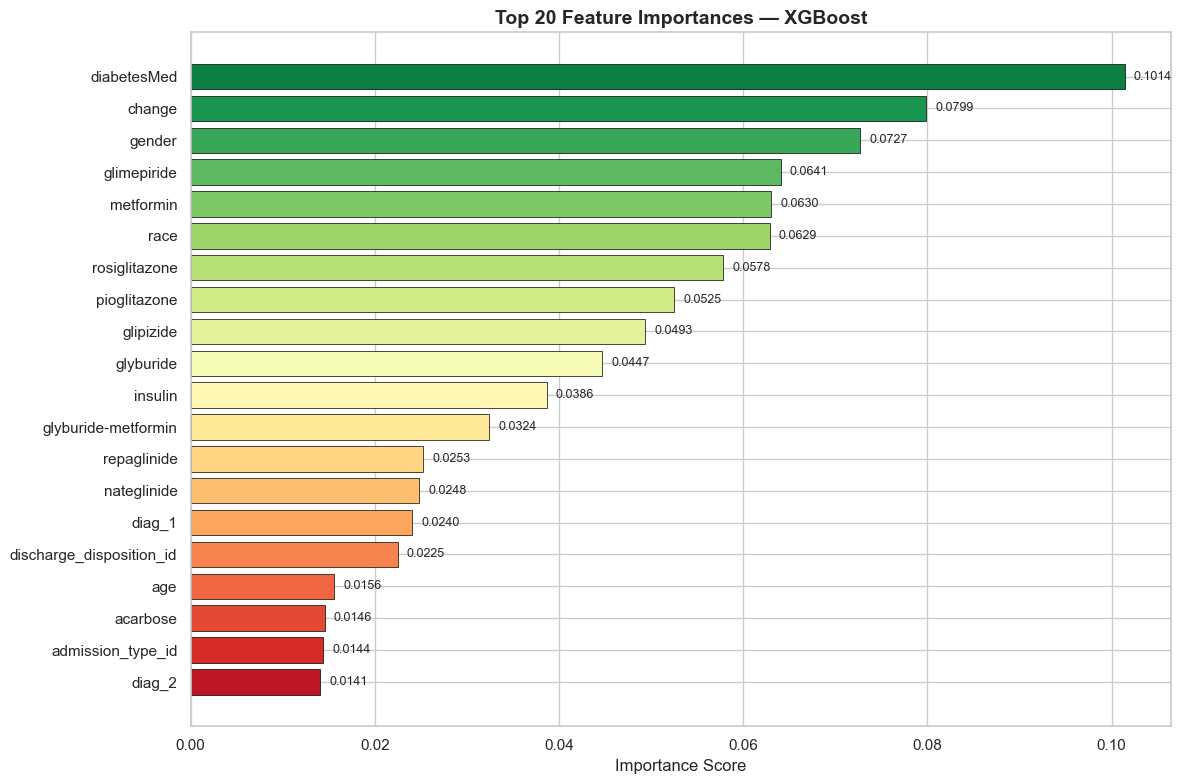

 Saved: models/chart4_feature_importance.png
 Saved top features list to models/top_features.pkl


In [31]:
# ----- CHART 4: Feature Importance (Top 20) -----
# Works for Random Forest and XGBoost
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(12, 8))
    colors_imp = sns.color_palette('RdYlGn_r', len(importance_df))
    bars = ax.barh(importance_df['Feature'][::-1],
                   importance_df['Importance'][::-1],
                   color=colors_imp[::-1], edgecolor='black', linewidth=0.5)
    ax.set_title(f'Top 20 Feature Importances — {best_model_name}',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.001, bar.get_y() + bar.get_height()/2,
                f'{w:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('../outputImg/chart24_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Saved: models/chart4_feature_importance.png')

    # Save top features list for Flask API
    top_features = importance_df['Feature'].tolist()
    joblib.dump(top_features, '../models/top_features.pkl')
    print(' Saved top features list to models/top_features.pkl')
else:
    print(' Feature importance not available for this model type')

In [ ]:
# 5-fold cross validation on best model to confirm performance is stable
from sklearn.model_selection import StratifiedKFold, cross_val_score

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

cv_model = XGBClassifier(n_estimators=200, scale_pos_weight=ratio,
                          random_state=42, eval_metric='logloss', verbosity=0)

# Stratified 5-fold — preserves class ratio in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run on ORIGINAL (non-SMOTE) training data
cv_scores = cross_val_score(cv_model, X_train, y_train,
                             cv=skf, scoring='roc_auc', n_jobs=1)

print(f'CV AUC Scores: {[round(s, 4) for s in cv_scores]}')
print(f'Mean AUC:      {cv_scores.mean():.4f}')
print(f'Std Dev:       {cv_scores.std():.4f}')

CV AUC Scores: [0.6176, 0.6275, 0.6216, 0.6332, 0.6268]
Mean AUC:      0.6253
Std Dev:       0.0053


In [33]:
joblib.dump(best_model, '../models/classification_model.pkl')


joblib.dump(list(X.columns), '../models/feature_columns.pkl')

results_df.to_csv('../data/classification_results.csv', index=False)